# Dataset Visualization

Visual inspection of the spike-encoded datasets used by the SNN framework:
1. MNIST after Difference-of-Gaussians (DoG) filtering
2. CIFAR-10 after whitening kernel preprocessing (Falez 2020)

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
import torchvision

from applications.datasets import MnistDataset, Cifar10WhitenedDataset
from spiking.preprocessing import apply_difference_of_gaussians_filter
from spiking.preprocessing.whitening_kernels import apply_whitening_kernels
from spiking.visualization import dog_to_rgb, whitened_to_rgb

DATA_DIR = "../data"

## 1. MNIST after Difference-of-Gaussians

In [4]:
mnist_test = MnistDataset(DATA_DIR, "test")
mnist_inputs = mnist_test.inputs       # (N, 28, 28) raw images
mnist_times = mnist_test.all_times     # (N, 2, 28, 28) DoG spike times
mnist_labels = mnist_test.outputs      # (N,)

print(f"MNIST test: {len(mnist_labels)} images")
print(f"  raw shape: {mnist_inputs.shape}")
print(f"  encoded shape: {mnist_times.shape}")

MNIST test: 10000 images
  raw shape: torch.Size([10000, 28, 28])
  encoded shape: torch.Size([10000, 2, 28, 28])


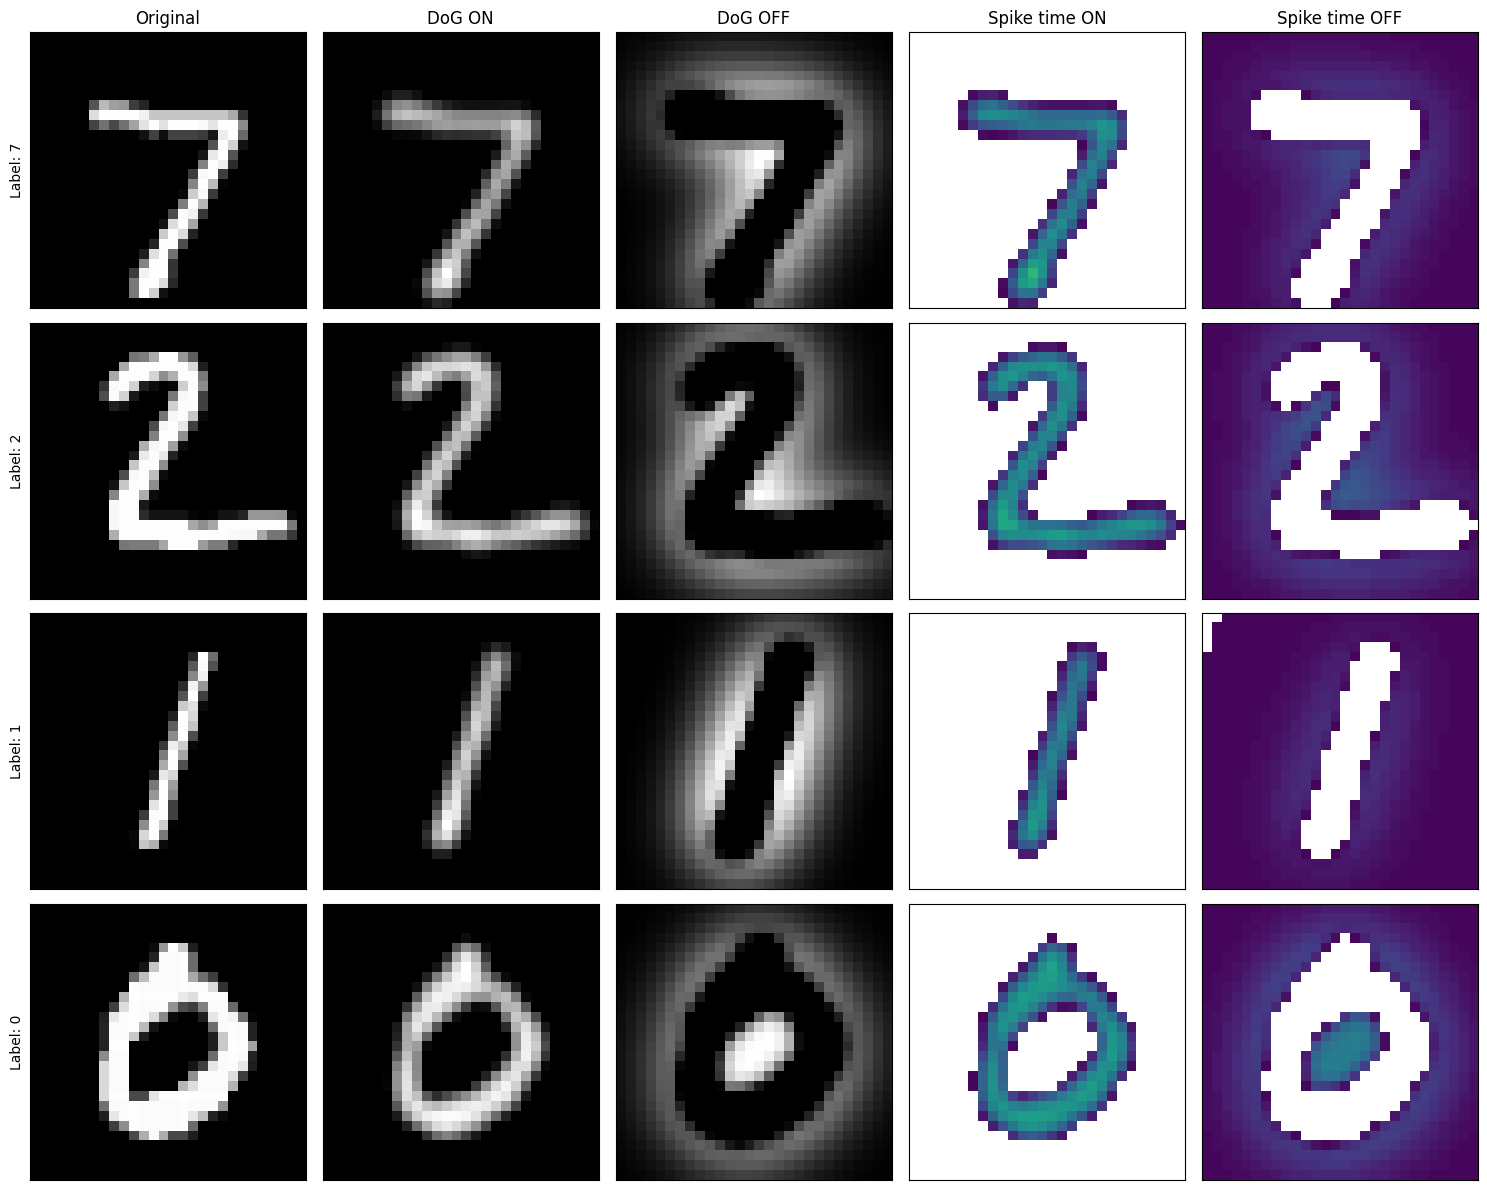

In [5]:
N_SAMPLES = 4

fig, axes = plt.subplots(N_SAMPLES, 5, figsize=(15, 3 * N_SAMPLES))
col_titles = ["Original", "DoG ON", "DoG OFF", "Spike time ON", "Spike time OFF"]

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title)

for row in range(N_SAMPLES):
    img = mnist_inputs[row]
    dog = apply_difference_of_gaussians_filter(img)
    times = mnist_times[row]
    label = mnist_labels[row].item()

    # Replace inf with NaN for display (shows as white)
    times_display = times.clone()
    times_display[~torch.isfinite(times_display)] = float("nan")

    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_ylabel(f"Label: {label}")
    axes[row, 1].imshow(dog[0], cmap="gray")
    axes[row, 2].imshow(dog[1], cmap="gray")
    axes[row, 3].imshow(times_display[0], cmap="viridis_r", vmin=0, vmax=1)
    axes[row, 4].imshow(times_display[1], cmap="viridis_r", vmin=0, vmax=1)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

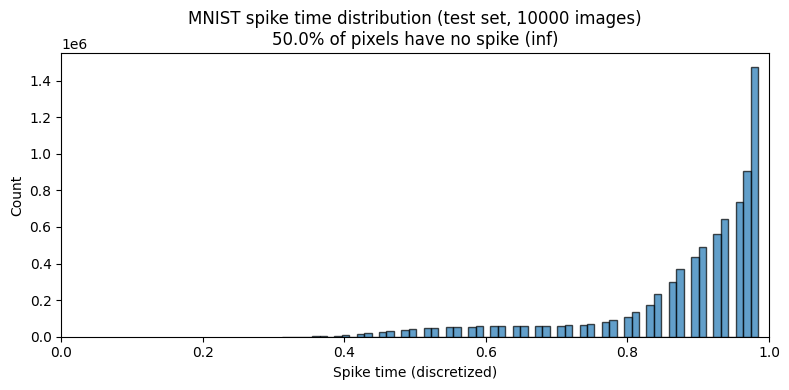

In [6]:
all_times_flat = mnist_times.ravel()
finite_times = all_times_flat[torch.isfinite(all_times_flat)]
inf_fraction = 1.0 - len(finite_times) / len(all_times_flat)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(finite_times.numpy(), bins=64, edgecolor="black", alpha=0.7)
ax.set_xlabel("Spike time (discretized)")
ax.set_ylabel("Count")
ax.set_title(
    f"MNIST spike time distribution (test set, {len(mnist_labels)} images)\n"
    f"{inf_fraction:.1%} of pixels have no spike (inf)"
)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

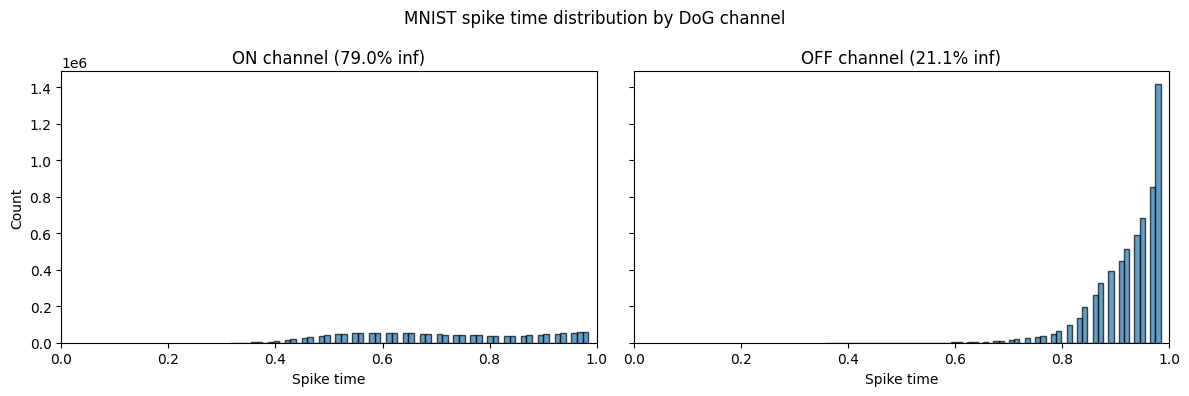

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
channel_names = ["ON", "OFF"]

for ch, (ax, name) in enumerate(zip(axes, channel_names)):
    ch_times = mnist_times[:, ch].ravel()
    finite = ch_times[torch.isfinite(ch_times)]
    inf_frac = 1.0 - len(finite) / len(ch_times)
    ax.hist(finite.numpy(), bins=64, edgecolor="black", alpha=0.7)
    ax.set_title(f"{name} channel ({inf_frac:.1%} inf)")
    ax.set_xlabel("Spike time")
    ax.set_xlim(0, 1)

axes[0].set_ylabel("Count")
fig.suptitle("MNIST spike time distribution by DoG channel")
plt.tight_layout()
plt.show()

## 2. CIFAR-10 after Whitening Kernels

In [8]:
# Load whitened CIFAR-10 with rho=1.0 (default)
cifar_train = Cifar10WhitenedDataset(DATA_DIR, "train")
cifar_test = Cifar10WhitenedDataset(
    DATA_DIR, "test", kernels=cifar_train.kernels, mean=cifar_train.mean,
)
test_times = cifar_test.all_times    # (N, 6, 32, 32)
test_labels = cifar_test.outputs     # (N,)

# Raw color images for display (no existing class exposes these)
cifar_raw = torchvision.datasets.CIFAR10(DATA_DIR, train=False, download=True)
raw_images = torch.from_numpy(cifar_raw.data).float() / 255.0  # (N, 32, 32, 3)

print(f"CIFAR-10 test (rho=1.0): {len(test_labels)} images")
print(f"  test_times shape: {test_times.shape}")

/Users/Razvan/CodeUni/dummy-snn/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR-10 test (rho=1.0): 10000 images
  test_times shape: torch.Size([10000, 6, 32, 32])


### Whitening kernels and output

Visualize the learned whitening kernels, then the whitened images: combined (RGB+ - RGB- scaled to [0,1]), RGB+ and RGB- channels.

Kernel shape: torch.Size([3, 3, 9, 9])


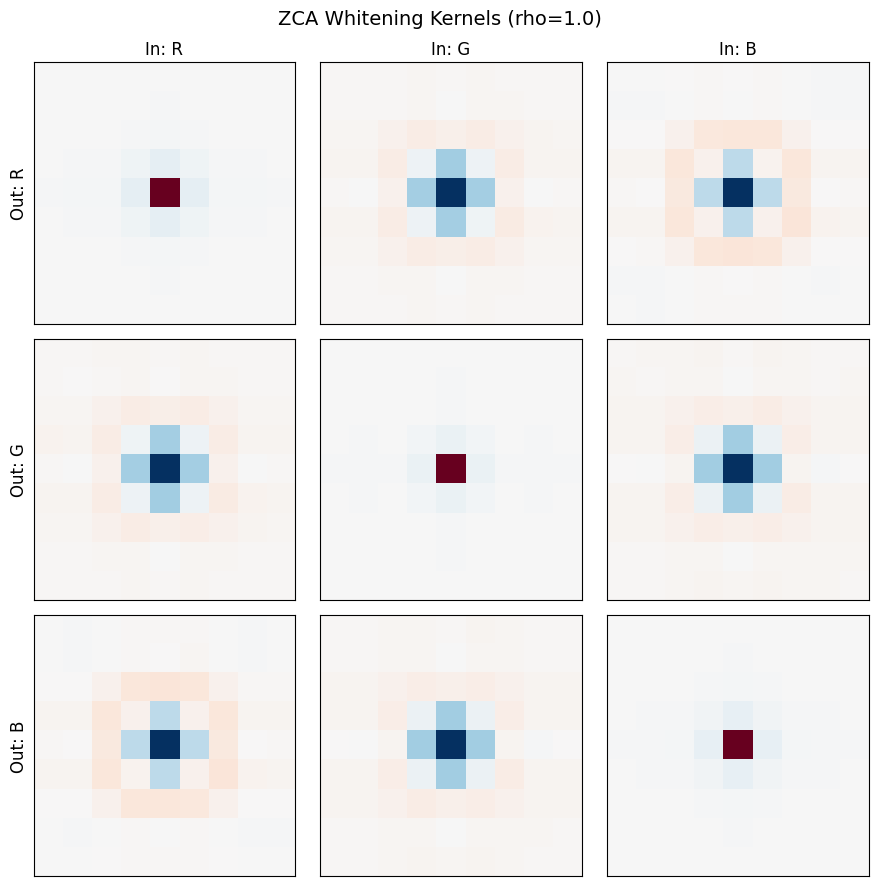

In [9]:
kernels = cifar_train.kernels
print(f"Kernel shape: {kernels.shape}")  # (C_out, C_in, kH, kW) = (3, 3, 9, 9)

# Plot kernels: each row = output channel (R, G, B), each col = input channel (R, G, B)
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
ch_labels = ["R", "G", "B"]
for out_ch in range(3):
    for in_ch in range(3):
        k = kernels[out_ch, in_ch].numpy()
        vmax = max(abs(k.min()), abs(k.max()))
        axes[out_ch, in_ch].imshow(k, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        axes[out_ch, in_ch].set_xticks([])
        axes[out_ch, in_ch].set_yticks([])
        if out_ch == 0:
            axes[out_ch, in_ch].set_title(f"In: {ch_labels[in_ch]}", fontsize=12)
        if in_ch == 0:
            axes[out_ch, in_ch].set_ylabel(f"Out: {ch_labels[out_ch]}", fontsize=12)

plt.suptitle("ZCA Whitening Kernels (rho=1.0)", fontsize=14)
plt.tight_layout()
plt.show()

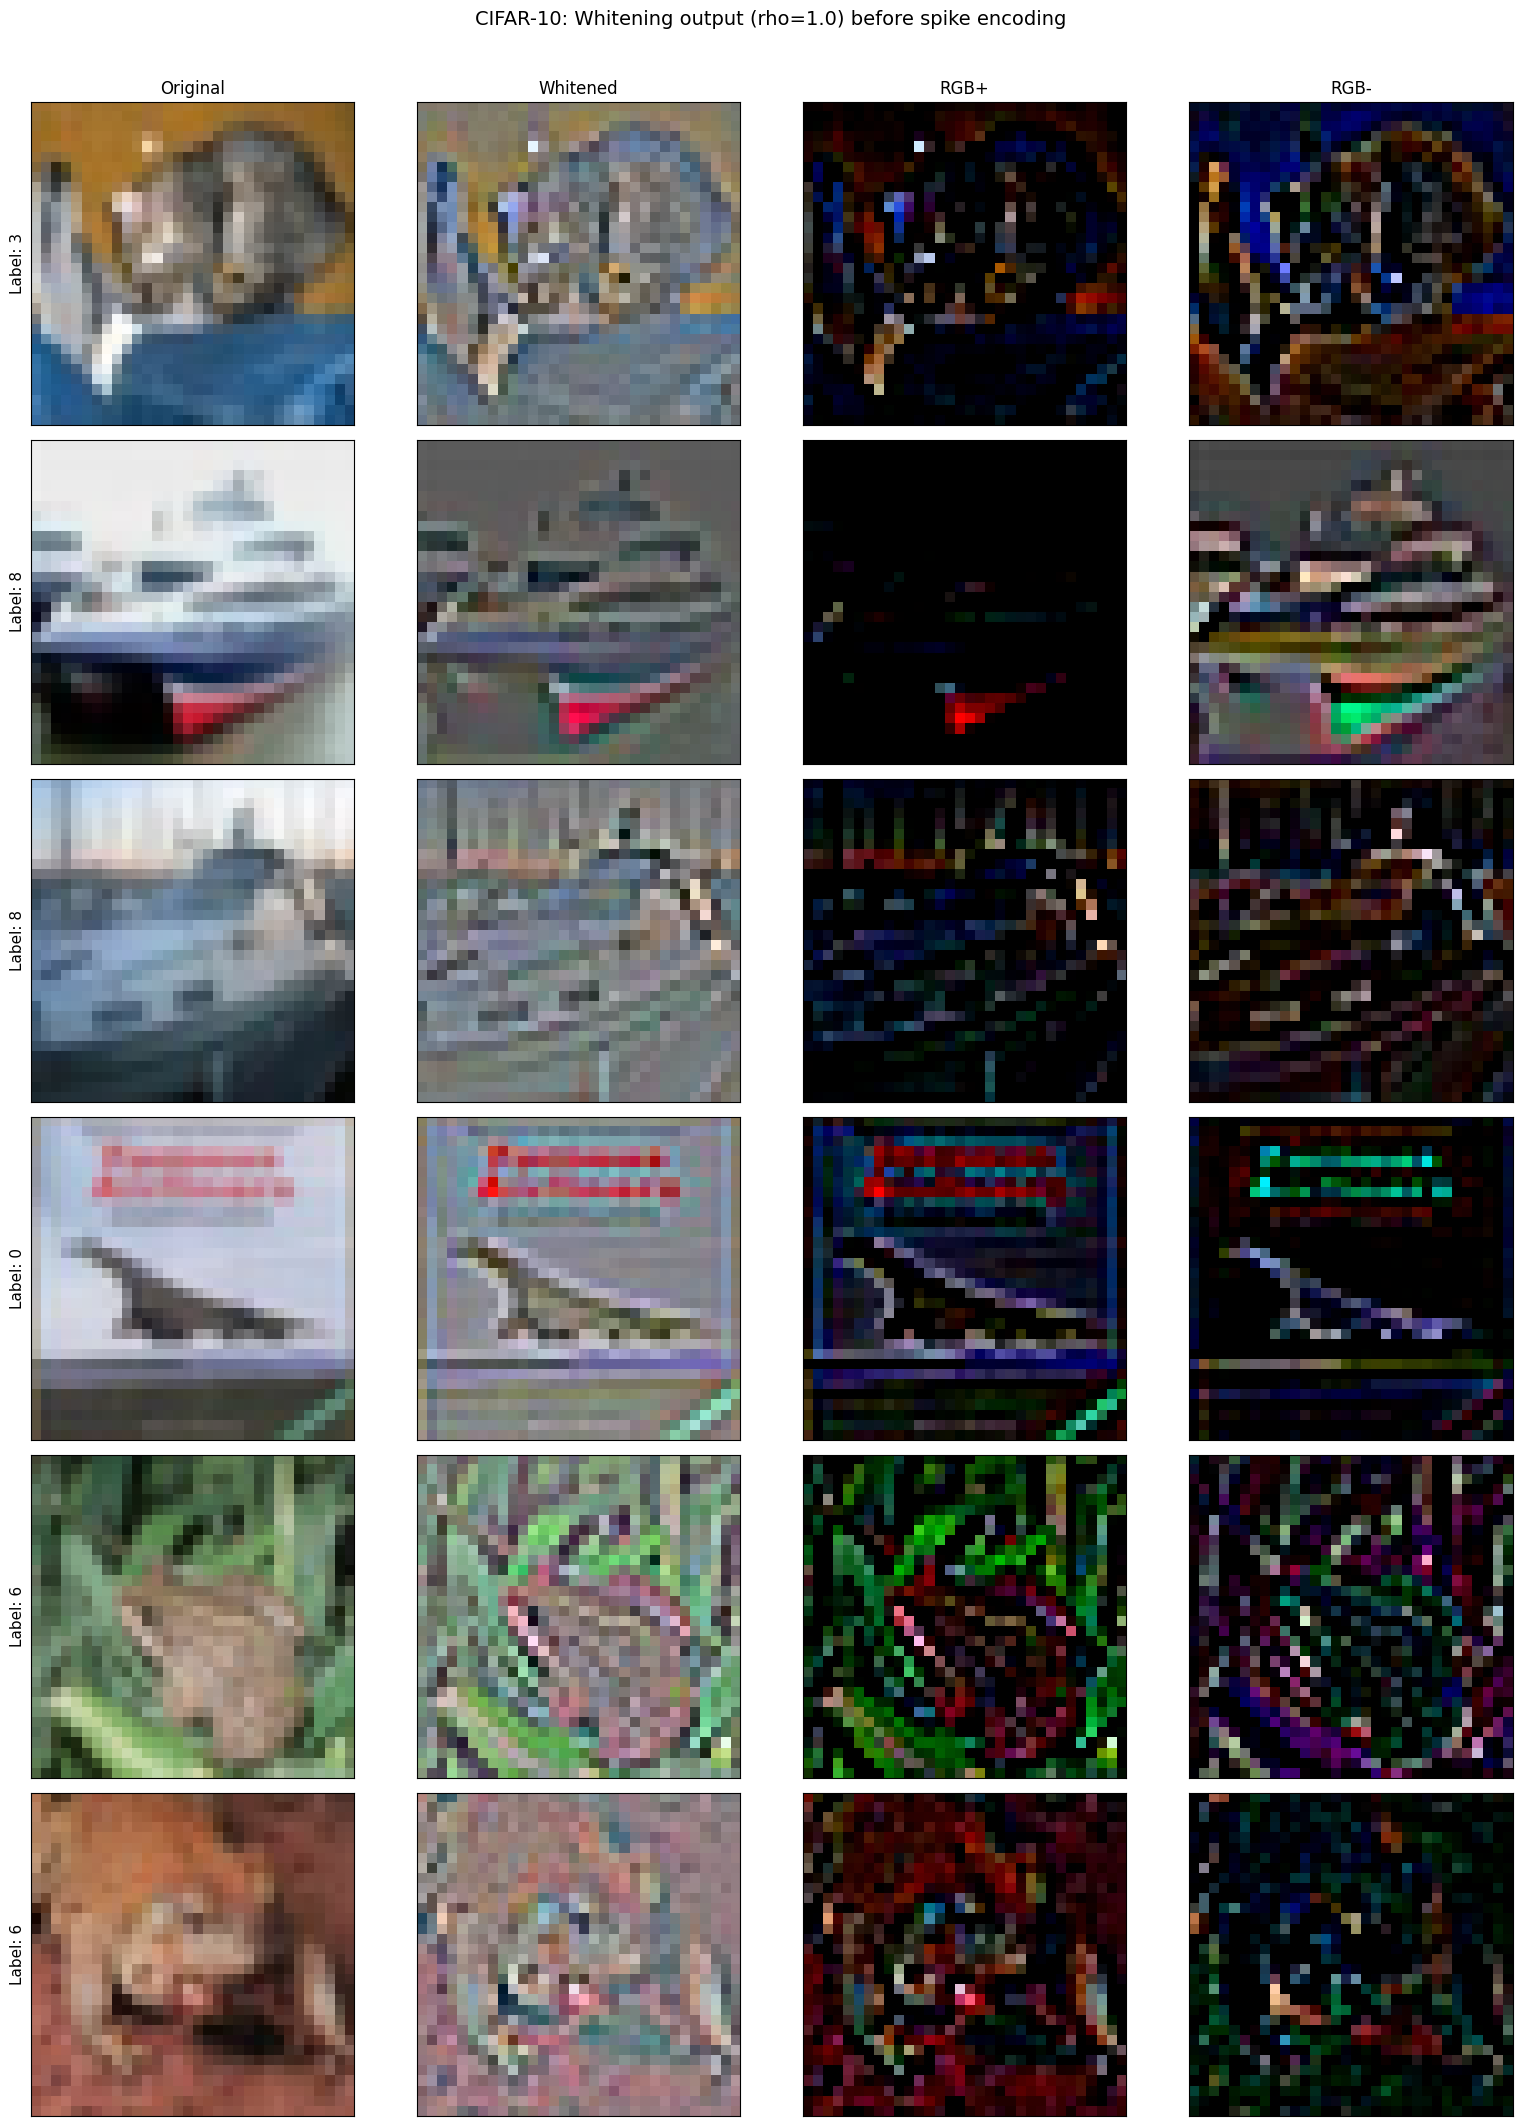

In [10]:
# Apply whitening to raw images for intermediate visualization
raw_chw = raw_images.permute(0, 3, 1, 2)  # (N, 3, 32, 32)
whitened = apply_whitening_kernels(raw_chw, cifar_train.kernels, cifar_train.mean)

N_SAMPLES = 6

fig, axes = plt.subplots(N_SAMPLES, 4, figsize=(16, 3.5 * N_SAMPLES))
col_titles = ["Original", "Whitened", "RGB+", "RGB-"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12)

for row in range(N_SAMPLES):
    label = test_labels[row].item()
    w = whitened[row]  # (3, 32, 32)

    # Per-sample min-max scale to [-1, 1] (same as encode_whitened_image)
    mn, mx = w.min(), w.max()
    scaled = 2.0 * (w - mn) / (mx - mn) - 1.0 if mx > mn else w

    pos = scaled.clamp(min=0)   # (3, H, W)
    neg = (-scaled).clamp(min=0)  # (3, H, W)

    # Combined: pos - neg is back to scaled [-1, 1], shift to [0, 1] for display
    combined = ((pos - neg) + 1.0) / 2.0  # [-1,1] -> [0,1]

    axes[row, 0].imshow(raw_images[row])
    axes[row, 0].set_ylabel(f"Label: {label}", fontsize=11)
    axes[row, 1].imshow(combined.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[row, 2].imshow(pos.permute(1, 2, 0).numpy())
    axes[row, 3].imshow(neg.permute(1, 2, 0).numpy())

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("CIFAR-10: Whitening output (rho=1.0) before spike encoding", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

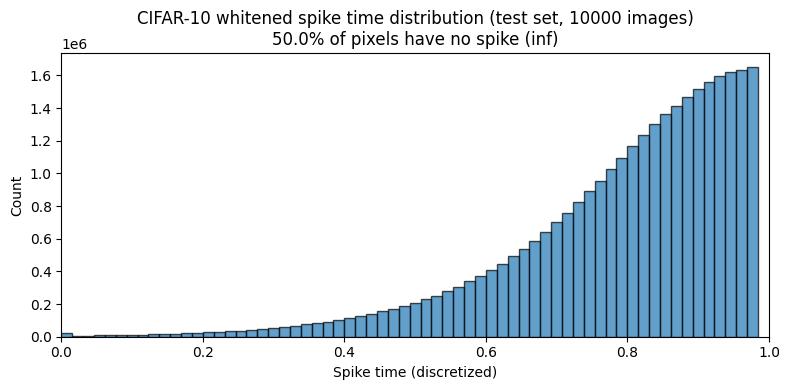

In [11]:
all_times_flat = test_times.ravel()
finite_times = all_times_flat[torch.isfinite(all_times_flat)]
inf_fraction = 1.0 - len(finite_times) / len(all_times_flat)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(finite_times.numpy(), bins=64, edgecolor="black", alpha=0.7)
ax.set_xlabel("Spike time (discretized)")
ax.set_ylabel("Count")
ax.set_title(
    f"CIFAR-10 whitened spike time distribution (test set, {len(test_labels)} images)\n"
    f"{inf_fraction:.1%} of pixels have no spike (inf)"
)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

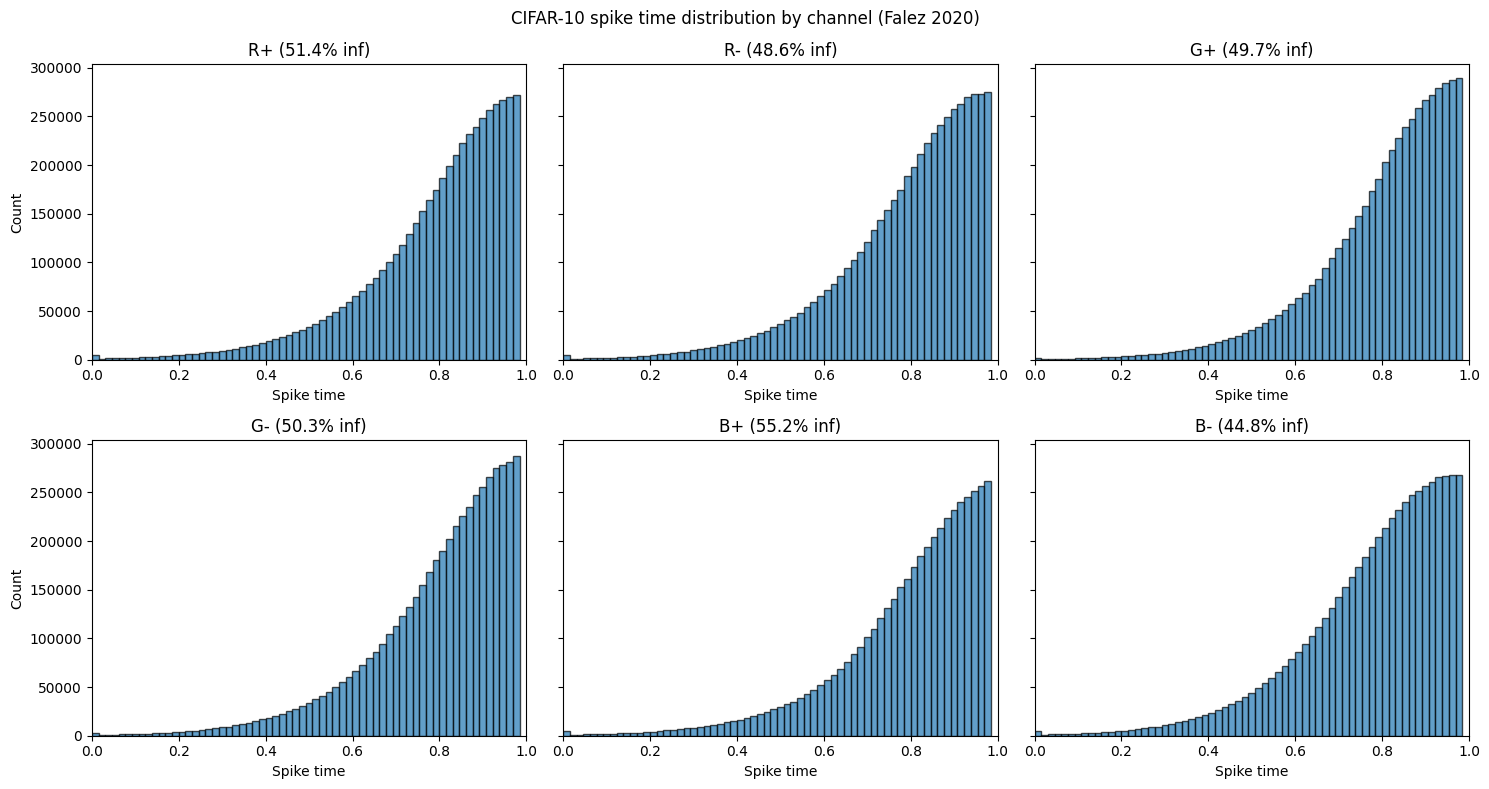

In [12]:
CHANNEL_NAMES = ["R+", "R-", "G+", "G-", "B+", "B-"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for ch, (ax, name) in enumerate(zip(axes.ravel(), CHANNEL_NAMES)):
    ch_times = test_times[:, ch].ravel()
    finite = ch_times[torch.isfinite(ch_times)]
    inf_frac = 1.0 - len(finite) / len(ch_times)
    ax.hist(finite.numpy(), bins=64, edgecolor="black", alpha=0.7)
    ax.set_title(f"{name} ({inf_frac:.1%} inf)")
    ax.set_xlabel("Spike time")
    ax.set_xlim(0, 1)

axes[0, 0].set_ylabel("Count")
axes[1, 0].set_ylabel("Count")
fig.suptitle("CIFAR-10 spike time distribution by channel (Falez 2020)")
plt.tight_layout()
plt.show()

## 3. Patch Extraction Visualization

Visualize the patch extraction pipeline: encoded images with patch positions marked, and the extracted 5×5 patches.

### 3a. MNIST patches (DoG-encoded, 5×5, 50 patches/image)

In [13]:
mnist_train = MnistDataset(DATA_DIR, "train", patch_size=5, num_patches=50)
mnist_train_inputs = mnist_train.inputs              # (N, 28, 28) raw
mnist_train_times = mnist_train.all_times            # (N, 2, 28, 28) spike times
mnist_train_labels = mnist_train.outputs             # (N,)
mnist_patch_positions = mnist_train.patch_positions   # (N, 50, 2)

print(f"MNIST train: {len(mnist_train_labels)} images")
print(f"  encoded shape: {mnist_train_times.shape}")
print(f"  patch_positions shape: {mnist_patch_positions.shape}")

MNIST train: 60000 images
  encoded shape: torch.Size([60000, 2, 28, 28])
  patch_positions shape: torch.Size([60000, 50, 2])


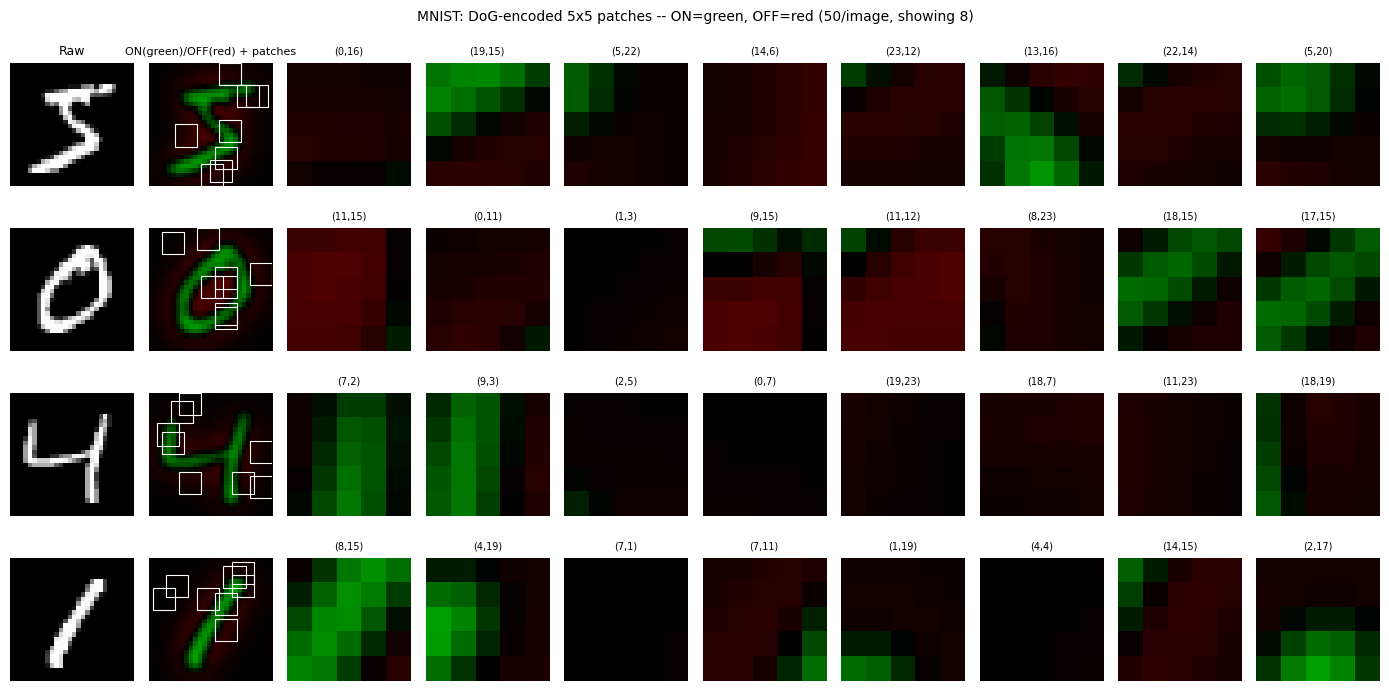

In [14]:
N_SAMPLES = 4
PATCHES_TO_SHOW = 8
PATCH_SIZE = 5

fig, axes = plt.subplots(N_SAMPLES, 2 + PATCHES_TO_SHOW, figsize=(2 + PATCHES_TO_SHOW * 1.5, N_SAMPLES * 1.8))

for img_idx in range(N_SAMPLES):
    raw_image = mnist_train_inputs[img_idx].numpy()
    encoded = mnist_train_times[img_idx]  # (2, H, W)
    positions = mnist_patch_positions[img_idx]  # (50, 2)
    label = mnist_train_labels[img_idx].item()

    # Col 0: raw image
    ax = axes[img_idx, 0]
    ax.imshow(raw_image, cmap="gray", vmin=0, vmax=1)
    if img_idx == 0:
        ax.set_title("Raw", fontsize=9)
    ax.set_ylabel(f"label={label}", fontsize=8)
    ax.axis("off")

    # Col 1: encoded ON=green, OFF=red with patch rectangles
    ax = axes[img_idx, 1]
    ax.imshow(dog_to_rgb(encoded))
    for p_idx in range(PATCHES_TO_SHOW):
        r, c = positions[p_idx, 0].item(), positions[p_idx, 1].item()
        rect = mpatches.Rectangle((c - 0.5, r - 0.5), PATCH_SIZE, PATCH_SIZE,
                                   linewidth=0.8, edgecolor="white", facecolor="none")
        ax.add_patch(rect)
    if img_idx == 0:
        ax.set_title(f"ON(green)/OFF(red) + patches", fontsize=8)
    ax.axis("off")

    # Cols 2+: extracted patches as red/green RGB
    for p_idx in range(PATCHES_TO_SHOW):
        ax = axes[img_idx, 2 + p_idx]
        r, c = positions[p_idx, 0].item(), positions[p_idx, 1].item()
        patch = encoded[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE]
        ax.imshow(dog_to_rgb(patch))
        ax.set_title(f"({r},{c})", fontsize=7)
        ax.axis("off")

plt.suptitle("MNIST: DoG-encoded 5x5 patches -- ON=green, OFF=red (50/image, showing 8)", fontsize=10)
plt.tight_layout()
plt.show()

### 3b. CIFAR-10 whitened patches (6-channel encoded, 5×5, 50 patches/image)

In [15]:
cifar_times = cifar_train.all_times       # (N, 6, 32, 32)
cifar_labels = cifar_train.outputs        # (N,)

# Raw color training images for display
cifar_raw_train = torchvision.datasets.CIFAR10(DATA_DIR, train=True, download=True)
raw_train_images = torch.from_numpy(cifar_raw_train.data).float() / 255.0  # (N, 32, 32, 3)

# Generate patch positions for visualization
PATCH_SIZE = 5
NUM_PATCHES = 50
H, W = 32, 32
rng = torch.Generator().manual_seed(42)
N = len(cifar_labels)
rows = torch.randint(0, H - PATCH_SIZE + 1, (N, NUM_PATCHES), generator=rng)
cols = torch.randint(0, W - PATCH_SIZE + 1, (N, NUM_PATCHES), generator=rng)
cifar_positions = torch.stack([rows, cols], dim=-1)  # (N, 50, 2)

print(f"CIFAR-10 whitened train (rho=1.0): {len(cifar_labels)} images, shape {cifar_times.shape}")
print(f"  Raw train images: {raw_train_images.shape}")
print(f"  Patch positions shape: {cifar_positions.shape}")

CIFAR-10 whitened train (rho=1.0): 50000 images, shape torch.Size([50000, 6, 32, 32])
  Raw train images: torch.Size([50000, 32, 32, 3])
  Patch positions shape: torch.Size([50000, 50, 2])


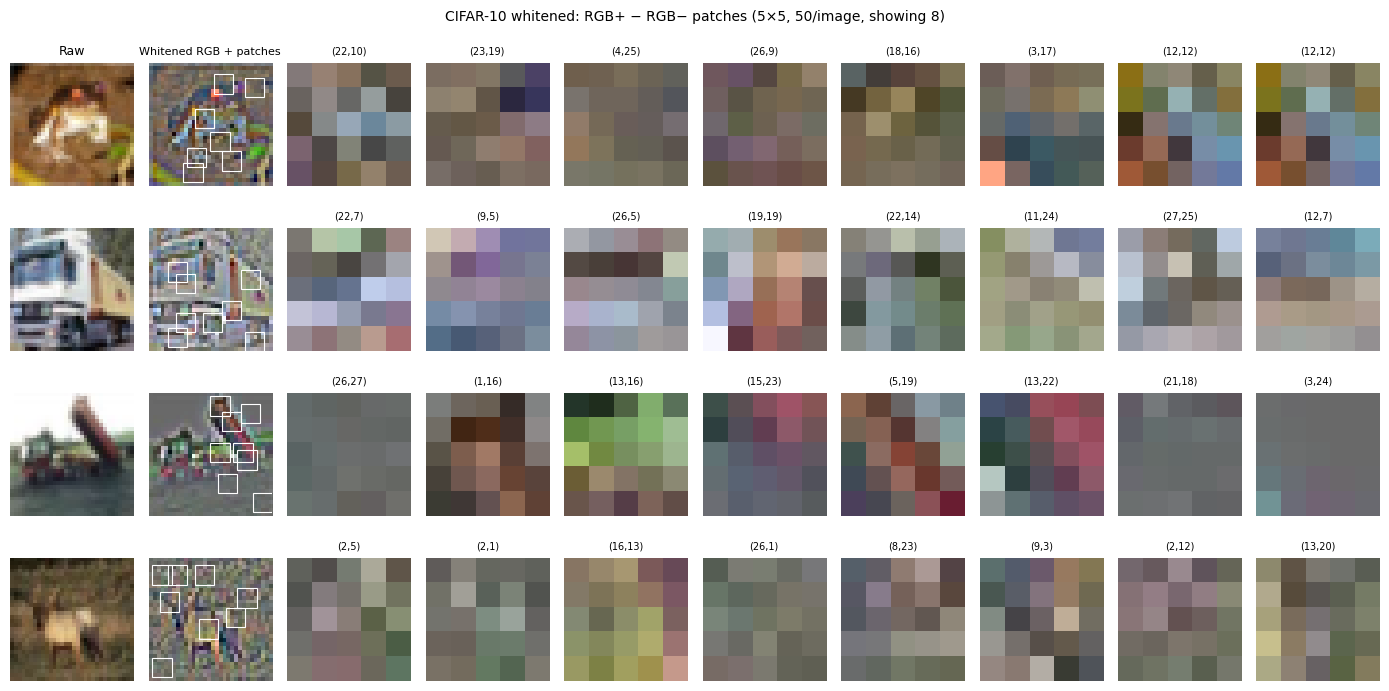

In [16]:
N_SAMPLES = 4
PATCHES_TO_SHOW = 8

fig, axes = plt.subplots(N_SAMPLES, 2 + PATCHES_TO_SHOW, figsize=(2 + PATCHES_TO_SHOW * 1.5, N_SAMPLES * 1.8))

for img_idx in range(N_SAMPLES):
    encoded = cifar_times[img_idx]  # (6, 32, 32)
    label = cifar_labels[img_idx].item()
    positions = cifar_positions[img_idx]  # (50, 2)

    # Col 0: raw CIFAR training image (matching the whitened data)
    ax = axes[img_idx, 0]
    ax.imshow(raw_train_images[img_idx])
    if img_idx == 0:
        ax.set_title("Raw", fontsize=9)
    ax.set_ylabel(f"label={label}", fontsize=8)
    ax.axis("off")

    # Col 1: whitened RGB (RGB+ - RGB- scaled to [0,1]) with patch rectangles
    ax = axes[img_idx, 1]
    ax.imshow(whitened_to_rgb(encoded))
    for p_idx in range(PATCHES_TO_SHOW):
        r, c = positions[p_idx, 0].item(), positions[p_idx, 1].item()
        rect = mpatches.Rectangle((c - 0.5, r - 0.5), PATCH_SIZE, PATCH_SIZE,
                                   linewidth=0.8, edgecolor="white", facecolor="none")
        ax.add_patch(rect)
    if img_idx == 0:
        ax.set_title(f"Whitened RGB + patches", fontsize=8)
    ax.axis("off")

    # Cols 2+: extracted patches as whitened RGB
    for p_idx in range(PATCHES_TO_SHOW):
        ax = axes[img_idx, 2 + p_idx]
        r, c = positions[p_idx, 0].item(), positions[p_idx, 1].item()
        patch = encoded[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE]
        ax.imshow(whitened_to_rgb(patch))
        ax.set_title(f"({r},{c})", fontsize=7)
        ax.axis("off")

plt.suptitle(f"CIFAR-10 whitened: RGB+ − RGB− patches ({PATCH_SIZE}×{PATCH_SIZE}, {NUM_PATCHES}/image, showing {PATCHES_TO_SHOW})", fontsize=10)
plt.tight_layout()
plt.show()

## 4. CIFAR-10 Training Logs (Falez 2020 Table I)

Visualize training dynamics across seeds: weight change convergence and threshold evolution.

To generate the logs, run from the project root:
```bash
python -m applications.conv_learning.train cifar10 --seeds 1 2 3 4 5 6 7 8 9 10
```

Logs are saved to `logs/cifar10_whitened/sweep/tobj_0.97/seed_*/`.

In [ ]:
from pathlib import Path

NF = 64  # Change to 256 to view 256-filter runs
LOGS_DIR = Path(f"../logs/cifar10_whitened/sweep/nf_{NF}/tobj_0.97")

# Load all seed logs
seed_logs = {}
for seed_dir in sorted(LOGS_DIR.glob("seed_*")):
    logs_path = seed_dir / "training_logs.pt"
    if logs_path.exists():
        seed = int(seed_dir.name.split("_")[1])
        seed_logs[seed] = torch.load(logs_path, weights_only=False)

print(f"Found {len(seed_logs)} seed logs (nf={NF}): {sorted(seed_logs.keys())}")
if seed_logs:
    sample = next(iter(seed_logs.values()))
    n_epochs = len(sample["epoch_mean_dw"])
    print(f"  Epochs per run: {n_epochs}")

In [ ]:
if seed_logs:
    epochs = np.arange(1, n_epochs + 1)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # --- Panel 1: Weight change convergence ---
    ax = axes[0, 0]
    all_dw = []
    for seed, logs in sorted(seed_logs.items()):
        dw = np.array(logs["epoch_mean_dw"])
        all_dw.append(dw)
        ax.plot(epochs, dw, alpha=0.3, linewidth=0.8, color="C0")
    mean_dw = np.mean(all_dw, axis=0)
    ax.plot(epochs, mean_dw, linewidth=2, color="C0", label=f"mean (n={len(seed_logs)})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean |dw|")
    ax.set_title("Weight change per epoch")
    ax.legend()
    ax.set_yscale("log")

    # --- Panel 2: Threshold mean evolution ---
    ax = axes[0, 1]
    all_th_mean = []
    for seed, logs in sorted(seed_logs.items()):
        th_mean = np.array(logs["epoch_threshold_mean"])
        all_th_mean.append(th_mean)
        ax.plot(epochs, th_mean, alpha=0.3, linewidth=0.8, color="C1")
    mean_th = np.mean(all_th_mean, axis=0)
    ax.plot(epochs, mean_th, linewidth=2, color="C1", label=f"mean (n={len(seed_logs)})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Threshold")
    ax.set_title("Mean threshold per epoch")
    ax.legend()

    # --- Panel 3: Per-neuron threshold traces (one seed) ---
    ax = axes[1, 0]
    sample_seed = sorted(seed_logs.keys())[0]
    th_per_neuron = seed_logs[sample_seed]["epoch_thresholds"]
    if isinstance(th_per_neuron, torch.Tensor):
        th_per_neuron = th_per_neuron.numpy()
    num_filters = th_per_neuron.shape[1]
    for f_idx in range(num_filters):
        ax.plot(epochs, th_per_neuron[:, f_idx], alpha=0.4, linewidth=0.6)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Threshold")
    ax.set_title(f"Per-neuron thresholds (seed {sample_seed}, {num_filters} filters)")

    # --- Panel 4: Neuron win distribution (one seed) ---
    ax = axes[1, 1]
    wins = seed_logs[sample_seed].get("neuron_wins")
    if wins is not None:
        if isinstance(wins, torch.Tensor):
            wins = wins.numpy()
        colors = ["C3" if w == 0 else "C0" for w in wins]
        ax.bar(range(len(wins)), wins, color=colors, edgecolor="black", linewidth=0.3)
        dead = int((wins == 0).sum())
        ax.set_title(f"Neuron win distribution (seed {sample_seed}, {dead} dead / {num_filters})")
    else:
        ax.set_title("Neuron wins not tracked (re-run training)")
    ax.set_xlabel("Neuron index")
    ax.set_ylabel("Win count")

    plt.suptitle("CIFAR-10 Training Dynamics (Falez 2020, t_obj=0.97, rho=1.0)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No training logs found. Run training first.")

In [ ]:
# Show all 64 learned filters for first seed + filter grid for 2 more seeds
if seed_logs:
    from spiking import load_model

    show_seeds = sorted(seed_logs.keys())[:3]

    for seed in show_seeds:
        model_path = LOGS_DIR / f"seed_{seed}" / "model.pth"
        if not model_path.exists():
            continue
        layer = load_model(str(model_path))
        w = layer.weights_4d.detach().cpu().numpy()  # (nf, C, kH, kW)
        nf = w.shape[0]
        ncols = min(16, nf)
        nrows = (nf + ncols - 1) // ncols

        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.1, nrows * 1.1))
        if nrows == 1:
            axes = axes[np.newaxis, :]

        for i in range(nrows * ncols):
            ax = axes[i // ncols, i % ncols]
            ax.axis("off")
            if i >= nf:
                continue
            filt = w[i]  # (C, kH, kW)
            rgb = filt[[0, 2, 4]].transpose(1, 2, 0)  # R+, G+, B+
            fmin, fmax = rgb.min(), rgb.max()
            if fmax > fmin:
                rgb = (rgb - fmin) / (fmax - fmin)
            ax.imshow(rgb, interpolation="nearest")

        plt.suptitle(f"Learned filters (seed {seed}, {nf} filters, R+/G+/B+ channels)", fontsize=11)
        plt.tight_layout()
        plt.show()